# Estimating Mountain Block Recharge Using a Bayesian State-Space Model  
*Final Report – Mikaela Bollag-Miller*
*Ecological Modeling Spring 2025*

## 1. Introduction

Groundwater holds a third of all freshwater resources and locally accounts for the sole source of drinking water in Missoula, MT (Pracht, 2001; Taylor et al., 2013). In the context of climate changes, this essential resource is impacted in complex and uncertain ways. Anthropogenically-driven climate change alters hydrologic cycling, with precipitation patterns in the western United States revealing a shift toward more arid conditions (Carroll et al., 2024; Meixner et al., 2016; Taylor et al., 2013). In the intermountain west, this is evidenced by declining snowpack and streamflow as well as earlier peak snowmelt and streamflow (Barnett et al., 2005; Mote et al., 2005). These hydrologic shifts create greater uncertainty in the quantity and timing of groundwater recharge from mountain aquifers to populated valleys (Markovich et al., 2021; Meixner et al., 2016; Taylor et al., 2013).

Mountain Block Recharge (MBR)- water sourced in the mountains which flows from mountain aquifers into adjacent lowland aquifers- is a critical but poorly quantified component of the groundwater system (Markovich et al. 2019). In the intermountain west, this key link in the groundwater system is a significant water source for alluvial aquifers, supplying up to 50% of total aquifer water resources in arid regions (Armengol et al., 2022; Markovich et al., 2019). MBR flows are poorly constrained in the scientific literature due to sparse observational data along the mountain front (Guan 2005; Wilson and Guan 2004). Modern groundwater quantification research has adopted integrated numerical modelling as a needed alternative which addresses these challenges (Markovich et al. 2021). Despite increasing effort to quantify groundwater resources, MBR remains poorly understood, with its temporal variability particularly lacking characterization (Markovich et al. 2019).

The Missoula Valley in western Montana provides a hydrologic system with geology characteristic of the intermountain west, and access to long-term, high-quality precipitation data and down-basin monitoring well data. However, modern assessments of its groundwater resources, particularly MBR, remain limited and dated (LaFave, 2002; Miller, 2001). Predictions of declining groundwater storage in the mountain west increase the urgency to better understand and quantify groundwater resources (Barnett et al., 2004; Carroll et al., 2024). Constraining MBR and its seasonal variability in a local watershed will inform local groundwater vulnerability and resilience, providing finer temporal resolution for forecasted declines. This study explores a Bayesian modeling approach to estimate recharge (R) entering the Missoula Valley and its seasonal dynamics, serving as a proxy for MBR.

#### Research Questions:

1. Is Bayesian state-space modeling an effective approach for estimating monthly recharge (R) entering the Missoula Valley over time?

2. What are the estimated monthly recharge (R) magnitudes entering the Missoula Valley, based on precipitation, temperature, and groundwater level change?

---

## 2. Data

### 2.1 Sources and Preprocessing

The precipitation and temperature data used in this study were obtained from the NOAA National Center for Environmental Information (NCEI). These monthly observational data for 2024 in Missoula, Montana were used as covariates in part of the model to inform predicted recharge.

The groundwater data used were sourced from monitoring wells maintained by the Missoula County Department of Public Health. This well network provides spatial coverage across the valley and consists of instrumented wells screened at varying depths within the Missoula Aquifer. Daily groundwater elevation measurements for 2024 from 19 wells were aggregated to monthly averages to reduce noise while preserving seasonal patterns. These point observations were then spatially interpolated across the valley for each month in the dataset using Ordinary Kriging, a geostatistical modelling technique. The produced 300×300 gridded groundwater elevation estimates were then averaged and differenced month-to-month to estimate change in groundwater height ($\Delta h$), providing a more representative valley-wide groundwater elevation signal. 

Specific yield {Sy}, the ratio of aquifer volume which is accessible for water storage and release, was then applied to these monthly storage change estimates to translate values into meaningful water quantities (given that Δℎ includes grain volume and is not a true measure of water level change). An empirical specific yield value of 0.2 was used, based on relevant literature and the dominant aquifer lithology, silty, sandy clay with gravel lenses, described in Miller (1991). Precipitation ($P$) and change in groundwater storage ($ΔS$) were both converted to units of meters, while temperature ($T$) data were converted to degrees Celcius for model use.




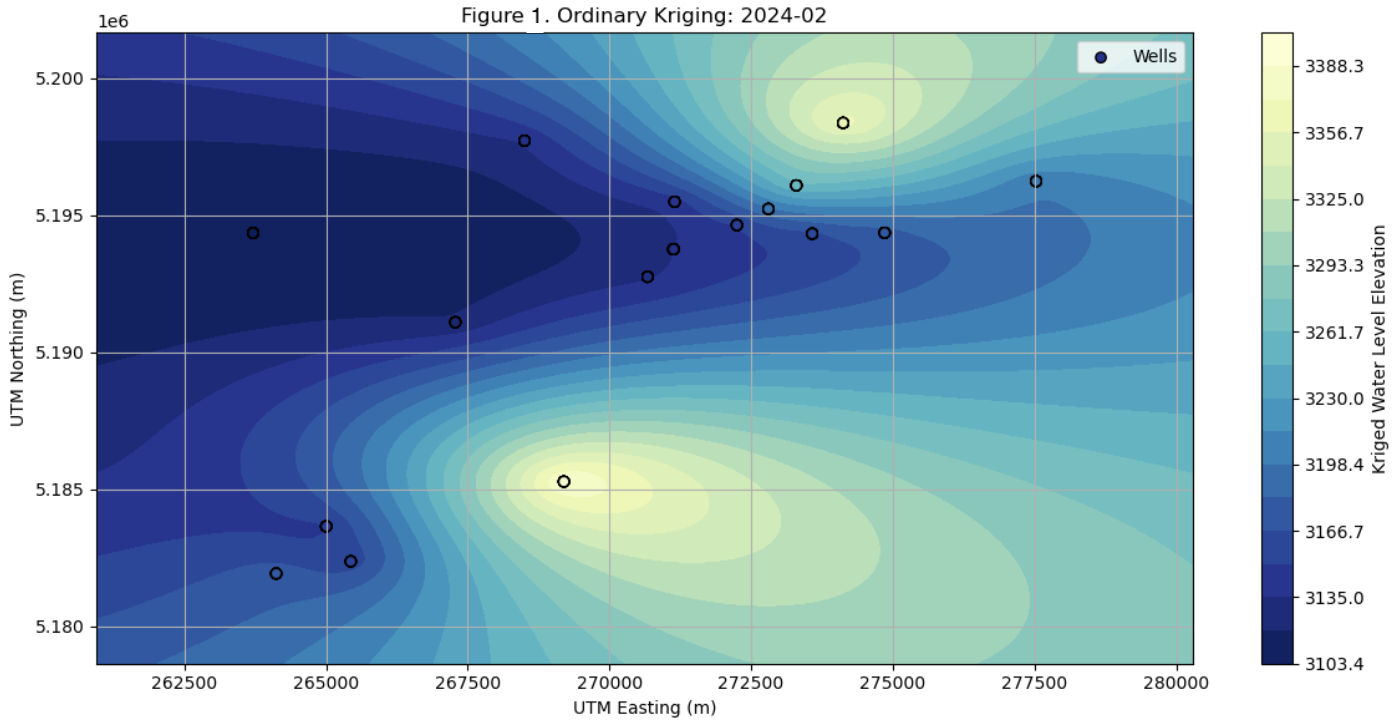
**Figure 1.** Kriged Groundwater Elevation Surface Example: February 2024 
Spatial interpolation of groundwater elevation. Elevation values (meters) are represented as a contoured surface across the Missoula Valley. Black circles denote well point observations used in the interpolation.

---

### 2.2 Water Balance Calculation

Prior to modeling, a physically based water balance was applied to calculate monthly groundwater recharge ($R_t$) estimates. The full water balance below was adapted and simplified given data availability. It should be noted that in the simplified water balance which was used here, recharge refers to all water that flows in or out of the Missoula Aquifer, which is not due to precipitation infiltration. 

The full water storage balance equation is:

$$
S_y \cdot \Delta S = P - ET + R - \Delta Q
$$

Where:

- $S_y$: specific yield (unitless)
- $\Delta S$: change in groundwater storage (m)
- $P$: precipitation (m)
- $ET$: evapotranspiration (m)
- $R$: groundwater recharge (m)
- $\Delta Q$: change in surface water (river systems) (m)

Due to time constraints, the scope of this project, and the difficulty of quantifying $ET$ and $\Delta Q$ in this setting, this simplified equation was used:

$$
\bar{R}_t = S_y \cdot \Delta \bar{S}_t - \bar{P}_t
$$

Where:

- $\bar{R}_t$: estimated recharge for month $t$
- $\Delta \bar{S}_t$: change in average groundwater storage for month $t$
- $\bar{P}_t$: average precipitation across the basin for month $t$

Recharge was calculated for each month assuming a constant $S_y = 0.2$.


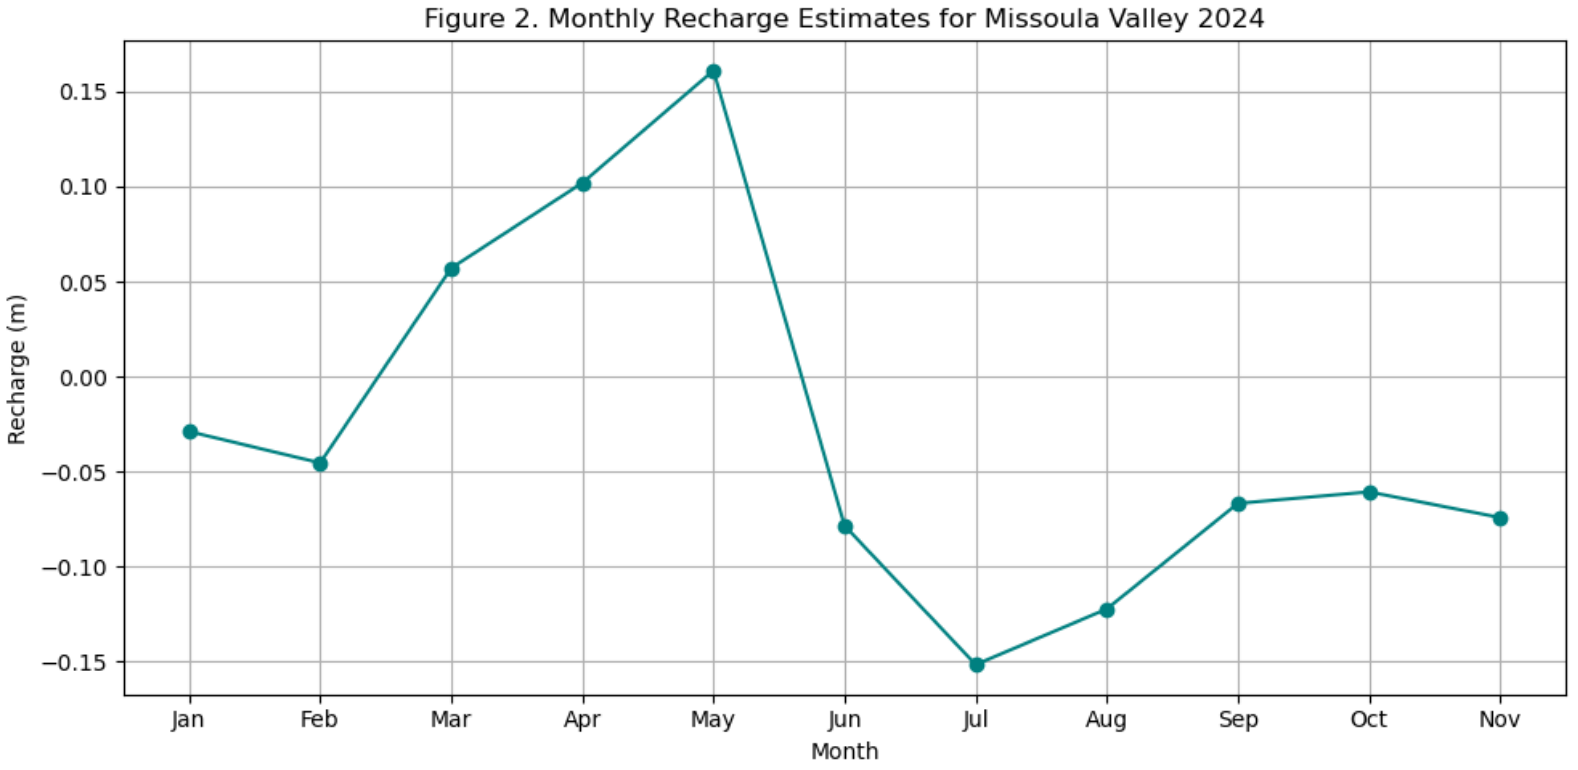
**Figure 2.** Monthly Recharge Estimates in Missoula Valley (2024)  
Estimated groundwater recharge (m) by month, showing seasonal variation. Calculated from simplified water balance.

---

### 2.3 Fake Data Generation

In order to appropriately test the state space model over an extended period, beyond the one year which was processed, synthetic monthly data for precipitation, temperature, and groundwater recharge were generated. This approach preserved observed seasonal patterns while introducing realistic, randomized variability. Precipitation and temperature values were drawn from normal distributions centered on their respective 2024 monthly means, with specified standard deviations to simulate natural fluctuations. Groundwater recharge values were similarly based on the seasonal pattern evident in the 2024 estimates, combined with random noise drawn from a normal distribution to mimic natural fluctuations.

The resulting precipitation and temperature time series were then normalized, by subtracting their respective means and dividing by their standard deviations, to aid model testing. Normalization ensures that both datasets are on comparable scales, and was completed in an effort to improve interpretation and comparison of the regression model coefficients.

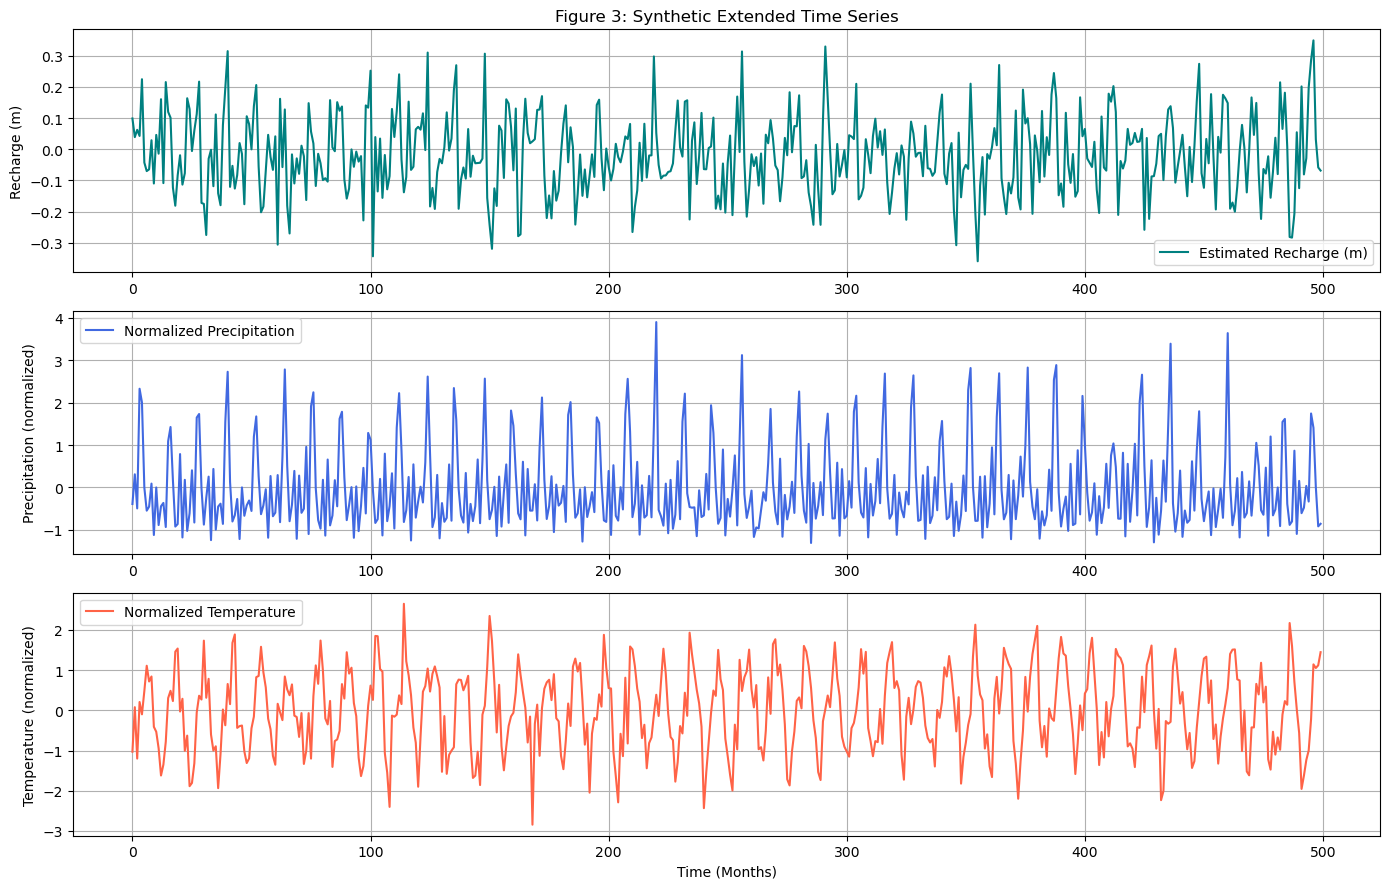
**Figure 3.** Synthetic Extended Time Series Data
Simulated monthly recharge, precipitation, and temperature over 500 months.  Precipitation and temperature data are normalized, in the form they were used for model testing.

---

## 3. Methods

### 3.1 State-Space Model Structure

This hierarchical State-Space model estimates unobserved latent monthly groundwater recharge ($R^{\text{true}}_t$) using untrustworthy water-balance-derived recharge estimates ($R_t$), climate covariates (precipitation $P_t$ and temperature $T_t$), and an autoregressive error structure. 

The model is composed of an **Observation Model** which connects latent recharge to estimated recharge. A **Latent Process Model** which predicts latent recharge from climate covariates given autoregressive error. And finally, an **Autoregressive Error Model** which accounts for time-correlated errors in recharge estimates from the process model, reflecting the reality that prior hydrolic conditions persist in time, making error temporally-dependent.

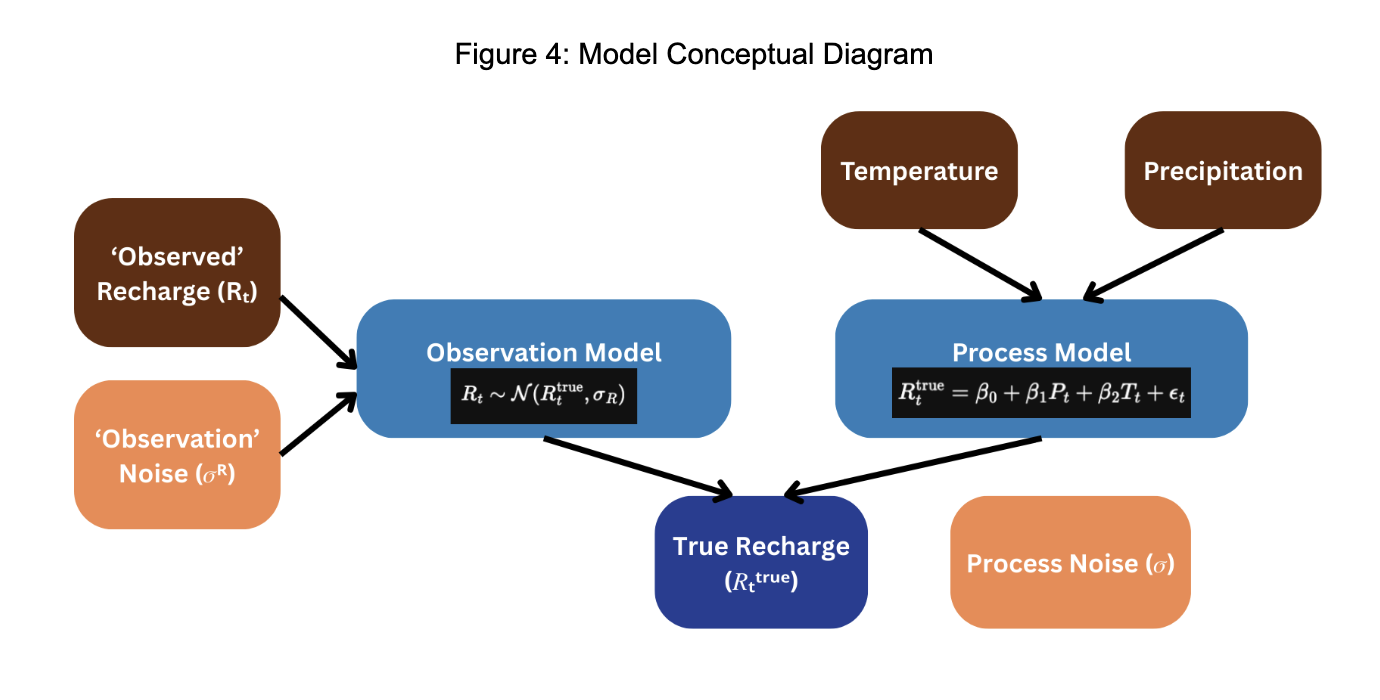
**Figure 4.** Conceptual diagram of Bayesian State-Space model structure

### 3.2 Model Equations

**Observation Model**  
Links the observed recharge to latent true recharge via observation uncertainty:

$$
R_t \sim \mathcal{N}(R^{\text{true}}_t, \sigma_R)
$$

---

**Latent Process Model**  
Recharge is modeled as a physically-based linear regression of precipitation and temperature covariates, with time-dependent error:

$$
R^{\text{true}}_t = \beta_0 + \beta_1 P_t + \beta_2 T_t + \epsilon_t
$$

---

**Autoregressive Error Process**  
The error term follows an autoregressive structure, allowing for past error to influence current error. This accounts for past hydrologic conditions influencing current conditions.

$$
\epsilon_1 \sim \mathcal{N}(0, \sigma)
$$

$$
\epsilon_t \sim \mathcal{N}(\phi \epsilon_{t-1}, \sigma) \quad \text{for } t > 1
$$

Where:  
- $R^{\text{true}}_t$: latent true recharge; the "hidden" actual recharge value, obscured in observational data 
- $R_t$: observed recharge; monthly recharge estimated from simplified Missoula Valley water balance  
- $\epsilon_t$: process error; time-correlated
- $P_t$: precipitation; a covariate in the regression model  
- $T_t$: temperature; another covariate in the regression model  
- $\beta_0$: intercept  
- $\beta_1$: effect of precipitation  
- $\beta_2$: effect of temperature  
- $\phi$: autoregressive coefficient  
- $\sigma$: process noise  
- $\sigma_R$: observation noise  
---
### 3.2 Priors

In developing this model, priors to inform each parameter were selected and rigorously tested to balance model fit with stability. This process was particularly challenging due to uncertainty in water-balance-derived recharge estimates, the scarcity of quantitative recharge data in the region, and the complexity of the model's error structure. Ultimately, regression coefficients ($\beta_0$, $\beta_1$, $\beta_2$) were assigned weakly informative normal priors centered at zero, with standard deviations reflecting anticipated effect sizes. The autoregressive parameter ($\phi$) was modeled with a more informative truncated normal prior, based on the expectation of moderate temporal autocorrelation in recharge error. This prior was forced between 0 and 1 to maintain realistic estimates and aid computational stability. 

Priors on the standard deviations of process error ($\sigma$) and observation error ($\sigma_R$) were tightly constrained half-normal distributions, with $\sigma_R$ assigned a highly informative prior based on the calculated standard deviation of the observed recharge data ($R$). These priors were highly tuned through model experiments and testing to reflect realistic recharge dynamics and address identifiability issues between process and observation error components. Their tightness improves model convergence by highly regularizing the estimation of observational noise ($\sigma_R$), and allowing for process noise ($\sigma$) to have slightly more flexibility. 

As discussed later, the identifiability issues between process and observation error persist, and the need to impose artificially tight priors reduces confidence in model flexibility and accuracy.

Priors Used:
$$
\begin{aligned}
\beta_0 &\sim \mathcal{N}(0, 10) \\
\beta_1, \beta_2 &\sim \mathcal{N}(0, 1) \\
\phi &\sim \mathcal{N}(0.7, 0.1) \; \text{T}[0, 1] \\
\sigma &\sim \mathcal{N}(0.05, 0.02) \; \text{T}[0,]) \\
\sigma_R &\sim \mathcal{N}(0.0957, 0.005) \; \text{T}[0,]) \\
\epsilon[1] &\sim \text{normal}(0, \sigma) 
\end{aligned}
$$

---

## 4. Results

### 4.1 Posterior Summaries  

**Table 1.** Posterior summaries for general model parameters. All $\hat{R}$ values are close to 1.0, indicating convergence, though $\phi$ and $\sigma$ show elevated R-hat values and low ESS, suggesting some sampling issues. The precipitation regression coefficient ($\beta_1$ mean = 0.05) showed positive effects on recharge estimates (particularly given normalization scaling), while temperature ($\beta_2$ mean = -0.018) showed no influence. The autoregressive parameter ($\phi$ mean = 0.23) indicates low to moderate temporal autocorrelation, though outputs show this estimate is unreliable given its high standard deviation, wide 95% credible interval, and poor convergence. The tight posterior on $\sigma_R$ reflects the highly informative prior, while $\sigma$ remains more uncertain, consistent with identifiability limitations.

| Parameter | Mean     | MCSE     | StdDev   | 95% CI (upper) | ESS_bulk | ESS_tail | $\hat{R}$ |
|-----------|----------|----------|----------|----------------|-----------|-----------|----------|
| $\beta_0$ | -0.0181  | 0.0001   | 0.0053   | -0.0092        | 2458.3    | 4240.5    | 1.002     |
| $\beta_1$ | 0.0505   | 0.0001   | 0.0050   | 0.0587         | 2023.0    | 3963.6    | 1.002     |
| $\beta_2$ | -0.0228  | 0.0001   | 0.0052   | -0.0141        | 2677.8    | 4236.4    | 1.001     |
| $\phi$    | 0.2312   | 0.0085   | 0.1369   | 0.4744         | 267.4     | 381.1     | 1.018     |
| $\sigma$  | 0.0493   | 0.0009   | 0.0106   | 0.0661         | 144.0     | 130.0     | 1.020     |
| $\sigma_R$| 0.0990   | 0.0002   | 0.0044   | 0.1060         | 292.3     | 781.4     | 1.009     |


Epsilon ($\epsilon_t$) Posterior summary: Autocorrelated error term. 

This term accounts for deviation of latent true recharge ($R^{\text{true}}_t$) from the climate-driven linear regression, with temporal structure imposed by the autoregressive coefficient $\phi$. While error is centered on zero as expected, there are large and frequent deviations from zero and high uncertainty. This indicates missing time-correlated dynamics in the process model.

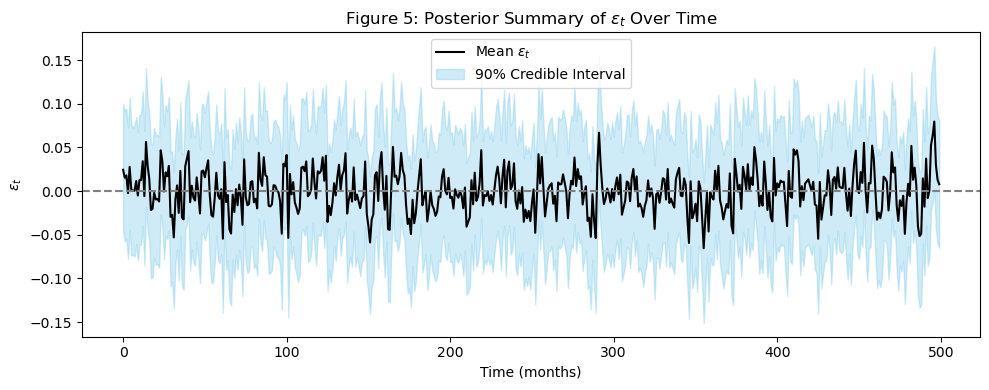
**Figure 5.** Posterior Summary of $\epsilon_t$ Over Time
Posterior mean and 90% credible interval for $\epsilon_t$, the time-correlated process error in the autoregressive component of the model. 


### 4.2 Model Fit: Time Series 
To evaluate model performance, predicted latent recharge ($R_t^{\text{true}}$) and posterior predictive simulations were compared against observed recharge ($R_t$) over the first 50 months (for pattern visibility). Posterior predictions follow latent recharge estimates with reasonable fit, though minor fluctuations are missed. Both the predicted ($R_{t,\text{pred}}^{\text{true}}$) and latent recharge ($R_t^{\text{true}}$) series are more smoothed than the noisy observed recharge ($R_t$), reflecting the model’s denoising effect. By adding the 95% credible interval (See Figure 6b), it's clear that the model captures broad recharge trends in the latent predictions. 

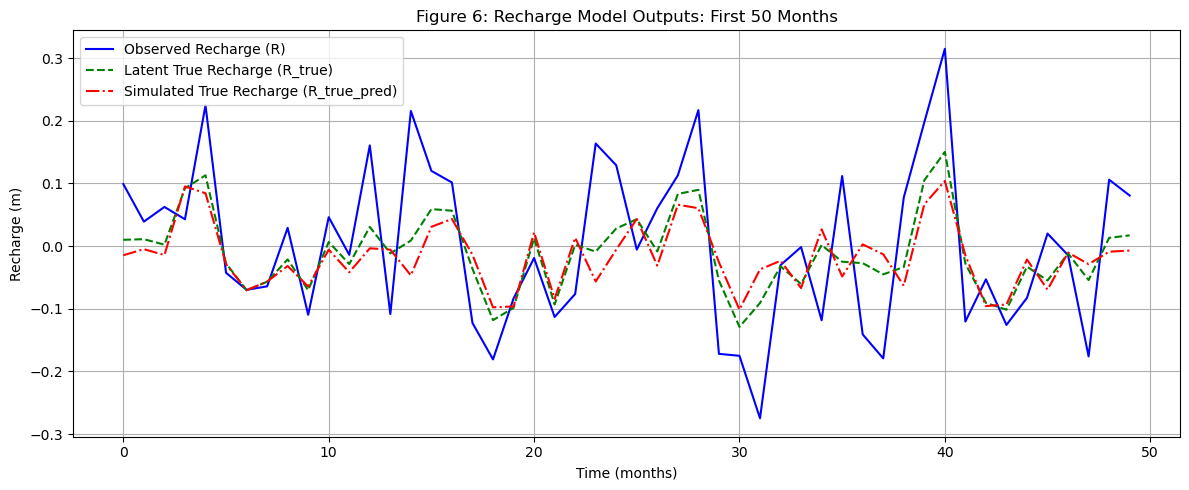
 
**Figure 6a.**  Posterior model outputs over the first 50 months. Recharge outputs: observed recharge ($R_t$), posterior mean of latent recharge ($R_t^{\text{true}}$), and posterior predictive simulation ($R_{t,\text{pred}}^{\text{true}}$). 

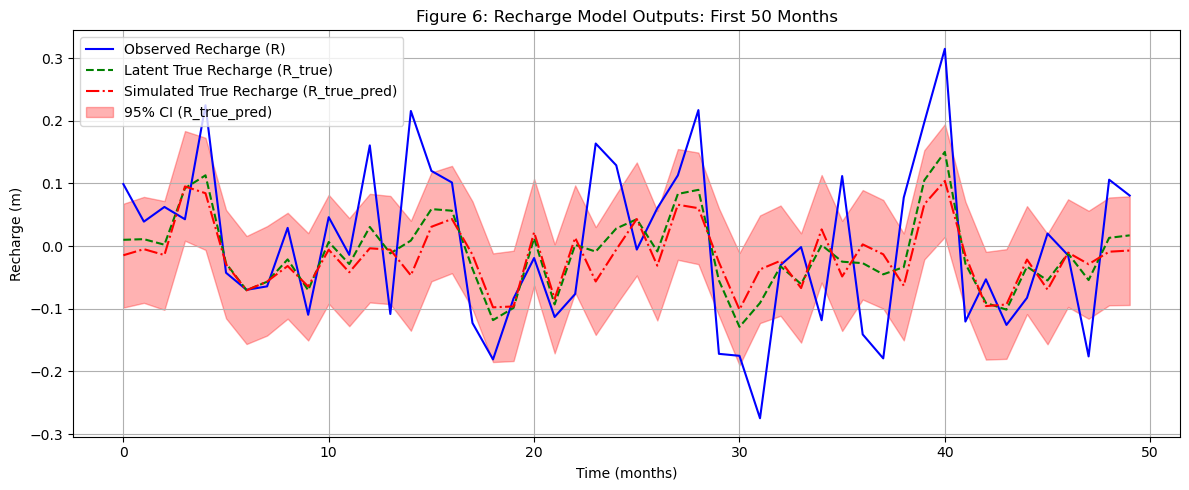 
**Figure 6b.** Same as Figure 6a, with 95% credible interval (shaded) around simulated recharge. 


### 4.3 Posterior Distributions  

Posterior distributions are generally centered, with $\beta_1$ (precipitation) showing a positive effect but substantial uncertainty. Notably, the posterior for $\phi$ is truncated near zero and exhibits a wide distribution, which is indicative of poor identifiability and limited learning from the data. $\sigma_R$ remains tightly constrained due to its informative prior, while $\sigma$ is broader, reflecting residual uncertainty in the process dynamics.

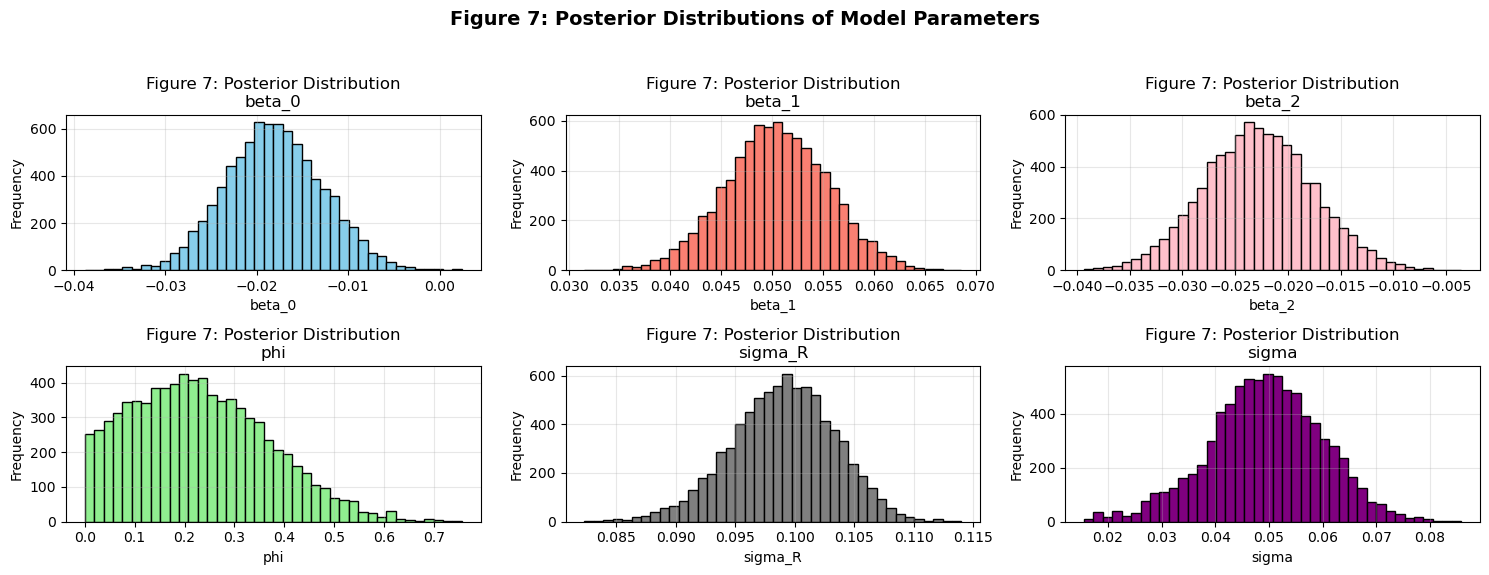
Figure 7. Posterior distributions of model parameters. Regression coefficients ($\beta_0$, $\beta_1$, $\beta_2$) and variance terms ($\sigma$, $\sigma_R$) are displayed

### 4.4 Convergence Diagnostics  

Trace plots are shown for parameters exhibiting signals of struggling convergence. There is poor mixing for $\phi$, with high chain variability and sampler challenges exploring the lower bounds (due to prior constraints), consistent with its diffuse and truncated posterior distribution. $\sigma$ chains appear better mixed, but have some chain separation, supporting earlier signals of identifiability issues between error terms. Despite these remaining convergence issues, these trace plots for parameters are far better mixed than earlier trials.

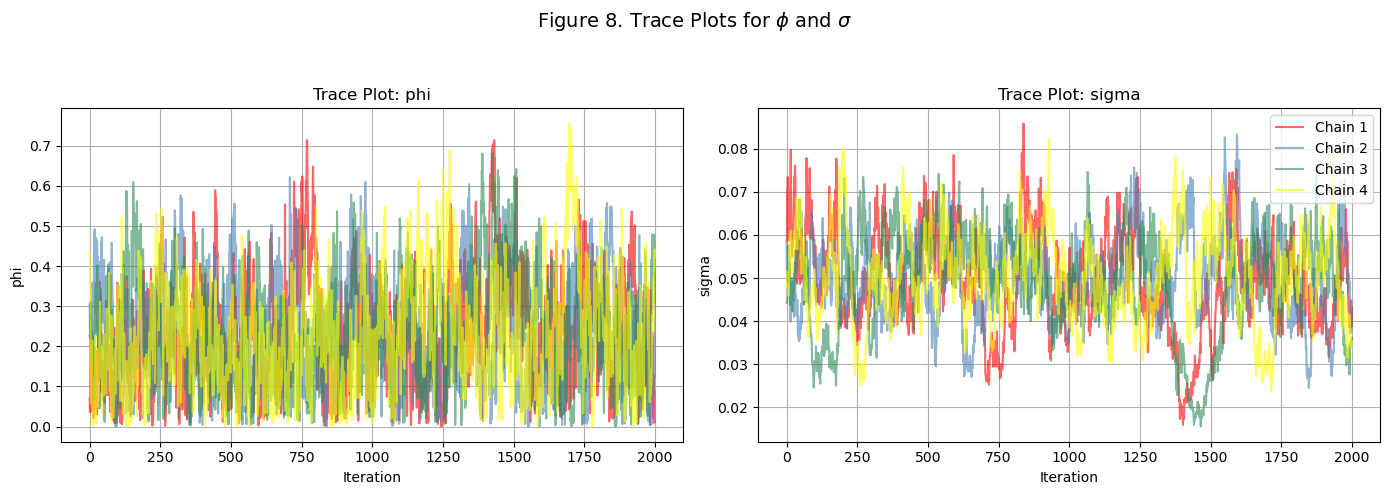
Figure 8. Trace plots for $\phi$ and $\sigma$ across four MCMC chains. 



---
## 6. Discussion and Future Work

Model results indicate that precipitation has a positive but uncertain effect on groundwater recharge, while temperature shows no meaningful influence. The time-correlated error term ($\epsilon_t$) varies systematically over time, departing from the expected random noise behavior. Given these findings, it is evident that the linear regression process model is missing key drivers of recharge patterns. While precipitation is a well-established control on recharge, supported both by model outputs and the broader scientific literature, temperature was included as a more accessible, though ultimately ineffective, proxy for snowmelt. Given that the Missoula Valley is a snow-dominated hydrologic system, this simplification limited the model’s ability to explain seasonal recharge variability. To improve model performance, snowmelt, as well as streamflow covariates should be included to better inform the climate-driven recharge estimates in this portion of the model.

Despite improved convergence over earlier iterations, the autoregressive component ($\phi$) remained weakly identified. Its wide posterior and elevated R-hat values reflect challenges in disentangling temporal error structure from observational noise and process noise. Given these results, in addition to convergence issues, $\phi$ estimates are largely unreliable and likely under-identified in the current model iteration.

The process error term $\sigma$ remains relatively large and uncertain, further highlighting that a substantial portion of recharge variability is not explained by the current climate covariates. In contrast, $\sigma_R$ is tightly constrained by its highly informative prior, which limits model exploration of uncertainty in this parameter. Together, these findings point to challenges in separating noise components and reinforce the conclusion that the linear process model omits important drivers of recharge dynamics. With a more informative process model, the autoregressive component would likely perform better, allowing cleaner partitioning of error and noise across the model. These improvements, along with incorporating longer time series of real data, and a more complete water balance approach to derive recharge, are the objective of future work on this model.

---

## 7. Conclusions 

Overall, Bayesian state-space modeling proved to be a useful approach for estimating monthly recharge seasonal patterns (if not yet true magnitudes), while incorporating uncertainty. The current iteration lacks complexity (in the process model) to fully take advantage of the autoregressive error structure. The model successfully captures broad recharge dynamics, and does provide a structure to separate latent recharge from noisy recharge observations, a significant improvement in quantifying this uncertain groundwater component. Addressing data accuracy and parameter identifiability will move this model toward producing more realistic recharge and uncertainty estimates for the Missoula Valley

---

## 8. References

**Armengol, S., Ajami, H., O’Sickman, J., & Ortega, L.** (2022). *Isogeochemical characterization of mountain system recharge processes in the Sierra Nevada, California*. Wiley. https://doi.org/10.1002/essoar.10512977.1

**Guan, H.** (2005). *Water above the mountain front – assessing mountain-block recharge in semiarid regions*.

**Markovich, K. H., Condon, L. E., Carroll, K. C., Purtschert, R., & McIntosh, J. C.** (2021). A mountain‐front recharge component characterization approach combining groundwater age distributions, noble gas thermometry, and fluid and energy transport modeling. *Water Resources Research, 57*(1), e2020WR027743. https://doi.org/10.1029/2020WR027743

**Markovich, K. H., Manning, A. H., Condon, L. E., & McIntosh, J. C.** (2019). Mountain‐block recharge: A review of current understanding. *Water Resources Research, 55*(11), 8278–8304. https://doi.org/10.1029/2019WR025676

**Miller, R. D.** (1991). *Numerical flow model of the Missoula Aquifer: Interpretation of aquifer properties and river interaction*.

**Pracht, K. A.** (2001). *Flow and aquifer parameter evaluation using groundwater age-dating geochemical tools and numerical modeling: Missoula aquifer, western Montana*.

**Wilson, J. L., & Guan, H.** (2004). Mountain-block hydrology and mountain-front recharge. In *Water Science and Application* (pp. 113–137). Washington, D.C.: American Geophysical Union. https://doi.org/10.1029/009wsa08


---

## 9. Appendix

1. Full Stan Code Block for state space model

2. Process Model experiment stan code block

3. Code for fake data generation from real data

In [ ]:
# --- Stan Model Code ---
stan_code = """
data {
    int<lower=1> N;
    vector[N] R;
    vector[N] P;
    vector[N] T;
}
parameters {
    real beta_0;
    real beta_1;
    real beta_2;
    real<lower=0, upper=1> phi;
    real<lower=1e-6> sigma;
    real<lower=1e-6> sigma_R;
    vector[N] R_true;
}
transformed parameters {
    vector[N] mu;
    vector[N] epsilon;
    for (t in 1:N) {
        mu[t] = beta_0 + beta_1 * P[t] + beta_2 * T[t];
        epsilon[t] = R_true[t] - mu[t];
    }
}
model {
//Priors
    beta_0 ~ normal(0, 10);
    beta_1 ~ normal(0, 1);
    beta_2 ~ normal(0, 1);
    phi ~ normal(0.5, 0.2) T[0, 1]; // normal(0.7, 0.1) T[0, 1] 
    sigma ~ normal(0.05, 0.02) T[0,]; // sigma ~ normal(0.1, .05) normal(0.05, 0.02) T[0,]; T[0,] sigma ~ normal(-1, 1);
    sigma_R ~ normal(0.0957, 0.005) T[0,]; // .01..
    epsilon[1] ~ normal(0, sigma);
    for (t in 2:N) {
        epsilon[t] ~ normal(phi * epsilon[t-1], sigma);
    }
    for (t in 1:N) {
        R[t] ~ normal(R_true[t], sigma_R);
    }
}
generated quantities {
    vector[N] R_true_pred;
    vector[N] epsilon_pred;
    vector[N] R_pred;
    vector[N] mu_pred;
    epsilon_pred[1] = normal_rng(0, sigma);
    for (t in 1:N) {
        real mu_t = beta_0 + beta_1 * P[t] + beta_2 * T[t];
        mu_pred[t] = mu_t;
        if (t > 1) epsilon_pred[t] = normal_rng(phi * epsilon_pred[t - 1], sigma);
        R_true_pred[t] = mu_t + epsilon_pred[t];
        R_pred[t] = normal_rng(R_true_pred[t], sigma_R);
    }
}
"""

In [ ]:
process_stan_code = """
data {
  int<lower=1> N;
  vector[N] R;  // now this is directly modeled
  vector[N] P;
  vector[N] T;
}

parameters {
  real beta_0;
  real beta_1;
  real beta_2;
  real<lower=1e-6> sigma;  // process uncertainty only
}

model {
  vector[N] mu;
  
  // Priors
  beta_0 ~ normal(0, 10);
  beta_1 ~ normal(0, 1);
  beta_2 ~ normal(0, 1);
  sigma ~ normal(0.1, 0.05) T[0,];  // tweakable

  // Likelihood
  for (t in 1:N)
    mu[t] = beta_0 + beta_1 * P[t] + beta_2 * T[t];

  R ~ normal(mu, sigma);  // observation = process output
}

generated quantities {
  vector[N] R_pred;
  for (t in 1:N)
    R_pred[t] = normal_rng(beta_0 + beta_1 * P[t] + beta_2 * T[t], sigma);
}
"""

In [ ]:
covariate_df = pd.read_csv('MA_model/temp_precip24.csv')
recharge_df = pd.read_csv('MA_model/recharge_estimates.csv')
P = covariate_df['precip_m'].values
T = (covariate_df['temp_F'].values - 32) * (5 / 9)
R = recharge_df['recharge_m'].values

# --- Generate Fake Climate and Recharge Series ---
np.random.seed(42)
N = 500
months = np.tile(np.arange(12), len(P) // 12 + 1)[:len(P)]
P_mean = P
T_mean = T
P_std = 0.2 * P
T_std = 5.0 * np.ones_like(T)

months_extended = np.tile(np.arange(12), N // 12 + 1)[:N]
P_fake = np.random.normal(P_mean[months_extended], P_std[months_extended])
T_fake = np.random.normal(T_mean[months_extended], T_std[months_extended])
recharge_12 = np.array([-0.0289, -0.0454, 0.0571, 0.1020, 0.1611, -0.0785,
                        -0.1516, -0.1223, -0.0668, -0.0607, -0.0742, -0.0320])
seasonal = np.tile(recharge_12, N // 12 + 1)[:N]
sigma_R = 0.0914
R_fake = seasonal + np.random.normal(0, sigma_R, size=N)

#Normalize P and T

P_norm = (P_fake - np.mean(P_fake)) / np.std(P_fake)
T_norm = (T_fake - np.mean(T_fake)) / np.std(T_fake)
